# Pens & Printers Sales Strategy Analysis

In [1]:
#importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('product_sales.csv')
df.head()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


In [2]:
#checking shape of dataset
df.shape

(15000, 8)

In [3]:
#checking inforamtion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [4]:
#exploring dataset by columns
df['sales_method'].unique()

array(['Email', 'Email + Call', 'Call', 'em + call', 'email'],
      dtype=object)

In [5]:
#checking for nulls
print(df['sales_method'].isnull().sum())
print(df['week'].isnull().sum())
print(df['customer_id'].isnull().sum())
print(df['nb_sold'].isnull().sum())
print(df['revenue'].isnull().sum())

0
0
0
0
1074


In [6]:
#checking for nulls
print(df['years_as_customer'].isnull().sum())
print(df['nb_site_visits'].isnull().sum())
print(df['state'].isnull().sum())

0
0
0


### Datatype Transformation

In [7]:
#changing dtypes
df['sales_method'] = df['sales_method'].astype('category')
df['customer_id'] = df['customer_id'].astype('category')
df['state'] = df['state'].astype('category')

#preview information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   week               15000 non-null  int64   
 1   sales_method       15000 non-null  category
 2   customer_id        15000 non-null  category
 3   nb_sold            15000 non-null  int64   
 4   revenue            13926 non-null  float64 
 5   years_as_customer  15000 non-null  int64   
 6   nb_site_visits     15000 non-null  int64   
 7   state              15000 non-null  category
dtypes: category(3), float64(1), int64(4)
memory usage: 1.3 MB


In [8]:
#checking summary statistics
df.describe()

,week,nb_sold,revenue,years_as_customer,nb_site_visits
count,15000.000000,15000.000000,13926.000000,15000.000000,15000.000000
mean,3.098267,10.084667,93.934943,4.965933,24.990867
std,1.656420,1.812213,47.435312,5.044952,3.500914
min,1.000000,7.000000,32.540000,0.000000,12.000000
25%,2.000000,9.000000,52.470000,1.000000,23.000000
50%,3.000000,10.000000,89.500000,3.000000,25.000000
75%,5.000000,11.000000,107.327500,7.000000,27.000000
max,6.000000,16.000000,238.320000,63.000000,41.000000


In [9]:
#checking years_as_customers above 30
df[df['years_as_customer'] > 30]

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
32,5,Call,57a6a6fd-842f-4b28-8033-b2137096f086,11,55.74,36,26,Colorado
535,3,Email,64ed5dea-a7cb-429f-b2af-2c236cab3ac3,10,95.30,32,26,Colorado
671,1,Email,93b798f3-9c6a-42d1-b339-b6b69c44f14a,8,83.71,36,22,Tennessee
719,1,Email,ae6df2ea-c55a-4251-803f-3daaf49d3f94,9,85.49,39,22,Texas
897,2,Email,7c98361a-3164-4931-bf0a-1d0a52dee087,10,96.83,33,24,Wyoming
1000,1,Email,ba91473b-4249-4567-bd42-23235b1c89bb,9,91.23,33,26,California
1070,1,Email,4f0b5cf1-8edf-4c89-8707-a977a5b5233a,8,80.16,31,22,California
1571,1,Call,b21f4243-622f-46b1-a856-64db5680c1b3,7,35.69,33,22,Ohio
1610,3,Call,8d1daff9-ec79-4fc4-808f-8ca001dda68f,8,41.31,32,26,Ohio
1676,1,Email,4ddd4f29-01b2-486d-b7dd-54cb1d45cab5,8,83.13,34,23,Ohio


In [10]:
#checking revenue below 100
df[df['revenue'] < 100]

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi
7,1,Email,047df079-071b-4380-9012-2bfe9bce45d5,10,99.94,1,22,Oklahoma
9,5,Call,56491dae-bbe7-49f0-a651-b823a01103d8,11,53.82,7,23,Missouri
...,...,...,...,...,...,...,...,...
14993,1,Email,3ec54950-652e-4d8a-bc49-8b5c770c6cd2,8,83.98,2,21,Texas
14995,4,Call,17267b41-d048-4346-8b90-7f787690a836,10,50.82,0,22,Pennsylvania
14996,5,Call,09e10d6f-4508-4b27-895e-4db11ce8302b,10,52.33,1,27,Kansas
14997,1,Call,839653cb-68c9-48cb-a097-0a5a3b2b298b,7,34.87,4,22,West Virginia


In [11]:
#replacing wrong sales_method is correct format
sales_method = df['sales_method']
sales_method = ['Email' if x == 'email' else x for x in sales_method]
sales_method = ['Email + Call' if x == 'em + call' else x for x in sales_method]
df['sales_method'] = sales_method


#checking unique sales method
df['sales_method'].unique()

array(['Email', 'Email + Call', 'Call'], dtype=object)

In [12]:
#setting a 5% threshold to drop or impute values for revenue
len(df)
df['revenue'].isnull().sum()
thresh = 0.05 * len(df)
thresh
if df['revenue'].isnull().sum() < thresh:
    print('drop')
else:
    print('impute')

impute


In [13]:
#cleaning and imputation
median_revenue = df['revenue'].median()
df['revenue'] = df['revenue'].fillna(median_revenue)

In [14]:
#visualizing sum of sales_method
sales_count = df['sales_method'].value_counts().reset_index()
sales_count

,sales_method,count
0,Email,7466
1,Call,4962
2,Email + Call,2572


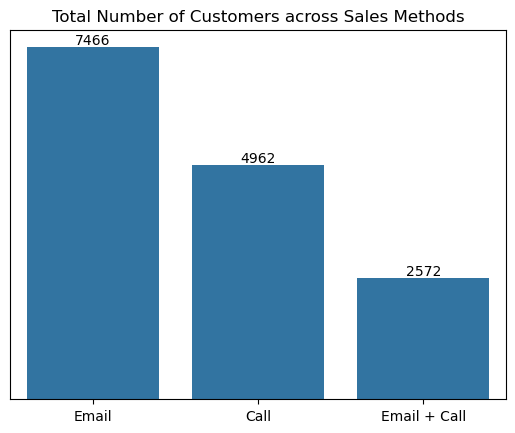

In [15]:
h = sns.barplot(data=sales_count, x='sales_method', y='count')
h.set_title("Total Number of Customers across Sales Methods")
h.set(xlabel="", ylabel="", yticks=[])
h.bar_label(h.containers[0])


plt.savefig('total_sales_methods.jpg')
plt.show()

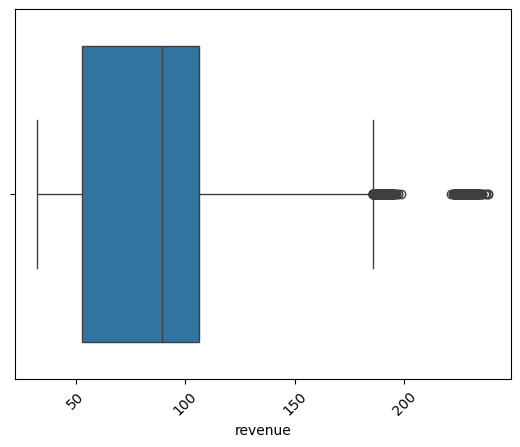

In [16]:
#visualizing spread of revenue
sns.boxplot(data=df, x='revenue', orient='h')
plt.xticks(rotation=45)
plt.show()

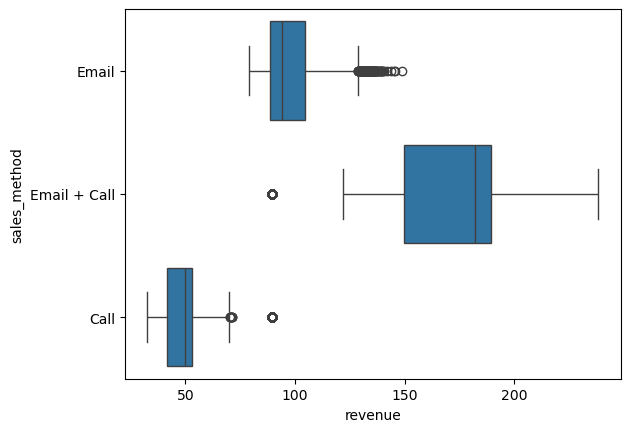

In [17]:
#revenue spread by sales methods
sns.boxplot(data=df, x='revenue', y='sales_method', orient='h')
plt.show()

In [18]:
#calculating revenue differences
total_revenue_by_weeks = df.groupby('week')['revenue'].sum().reset_index()
difference= []

for week in total_revenue_by_weeks['week']:
    if week == 1:
        difference.append(0)
    elif week == 2:
        diff1 = total_revenue_by_weeks['revenue'][1] - total_revenue_by_weeks['revenue'][0]
        difference.append(diff1)
    elif week == 3:
        diff2 = total_revenue_by_weeks['revenue'][2] - total_revenue_by_weeks['revenue'][1]
        difference.append(diff2)
    elif week == 4:
        diff3 = total_revenue_by_weeks['revenue'][3] - total_revenue_by_weeks['revenue'][2]
        difference.append(diff3)
    elif week == 5:
        diff4 = total_revenue_by_weeks['revenue'][4] - total_revenue_by_weeks['revenue'][3]
        difference.append(diff4)
    elif week == 6:
        diff5 = total_revenue_by_weeks['revenue'][5] - total_revenue_by_weeks['revenue'][4]
        difference.append(diff5)
        
total_revenue_by_weeks['difference'] = difference
#preview total_revenue_by_weeks
total_revenue_by_weeks

,week,revenue,difference
0,1,292858.06,0.00
1,2,213095.82,-79762.24
2,3,197559.55,-15536.27
3,4,252504.56,54945.01
4,5,273317.28,20812.72
5,6,174925.74,-98391.54


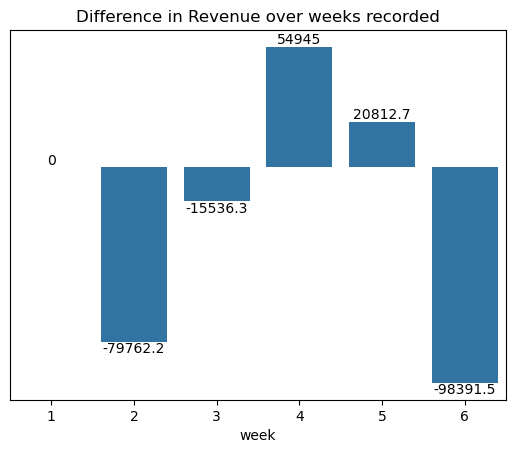

In [19]:
#Visualizing revenue differences by weeks
t = sns.barplot(data=total_revenue_by_weeks, x='week', y='difference')
t.set_title("Difference in Revenue over weeks recorded")
t.bar_label(t.containers[0])
t.set(yticks=[], ylabel="")

plt.savefig('revenue_difference.jpg')
plt.show()

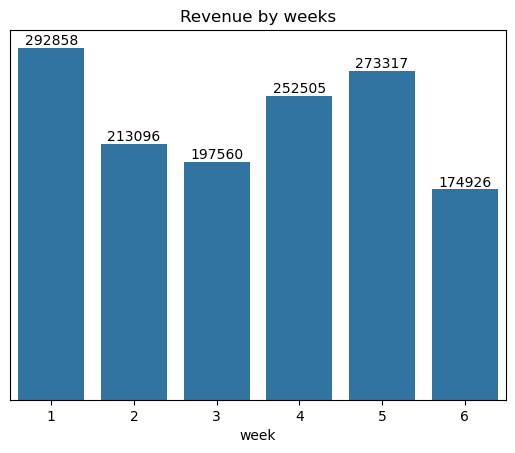

In [20]:
#Visualizing revenue differences by weeks
t = sns.barplot(data=total_revenue_by_weeks, x='week', y='revenue')
t.set_title("Revenue by weeks")
t.bar_label(t.containers[0])
t.set(yticks=[], ylabel="")

plt.show()

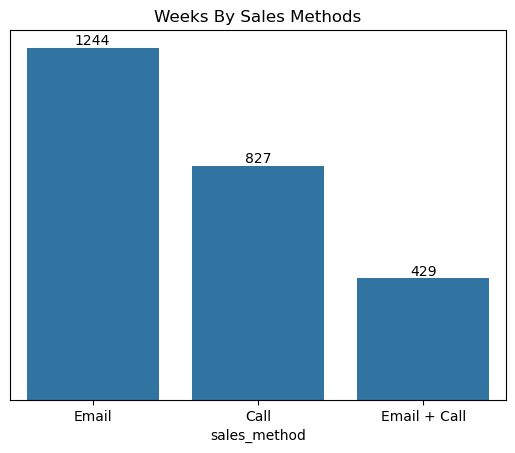

In [21]:
#visualizing weeks by the sales methods
week_method = df.groupby(['sales_method','week']).size().reset_index(name='count')
week_method = week_method.sort_values(by='week', ascending=False)

c = sns.barplot(data=week_method, x='sales_method', y='count', errorbar=None)
c.set_title("Weeks By Sales Methods")
c.bar_label(c.containers[0], fmt='%.0f')
c.set(yticks=[], ylabel="")



plt.show()

In [22]:
#Based on the dataset, we can work out the CES will be
Total_site_visits = df['nb_site_visits'].sum()

Average_CES = Total_site_visits/len(df)
print(Average_CES)

24.990866666666665


#### To: Sales rep
#### Read by: Head of Analytics
#### Subject: Sales Strategy Report

Product Sales Summary
An analysis on the sales approaches for the new product line. The analysis provides insight on the revenue of the new product line highlighting the number of products sold, the number of customers and their preferred sales method.

Data analysis tool used is SQL. Trimmed all variables before working on dataset.

# Data Validation
1. Inconsistent data types and data format.
Week: int data type and no missing data.
Nb_sold: int data type and no missing data.
Years as customer: int data type and no missing data.
Nb_site_visits: int data type and valid zero input recorded.
State: text data type and no missing values.

Sales_method: text datatype but has 5 unique category instead of 3. Wrong data format replaced with the correct data format.

Revenue: text data type converted to decimal. Missing data filled with median values of revenue.

# Exploratory Analysis
 ### Total Number of customers
- Based on the findings, most customers preferred the email approach followed by call strategy and a combination of both email and call strategy was the least.

### Spread of revenue
- Based on the findings, revenue spread has the majority between 80 - 100. Beyond which there is a decline indicating how much the customers are ready to spend on the average so we can tailor our sales to cut down budget and also meet customer demands.

- One graphic showing two or more variables. 
Comparing revenue spread by the individual sales methods, a combination of email and call recorded the highest revenue for the business and email ranked second with calls being the least. However, email was the main strategy to have recorded very high outliers indicating that very few customer activities yield higher sales hence further investigations must be made about revenue above 120 to be sure the business captures the right data.

The combination of email and call had the highest range of revenue values and the highest median value indicating that this strategy generates more revenue on the average hence must be considered when the business focus is on revenue.

# Definition of a metric for the business to monitor
One metric to consider is the Customer Engagement Score (CES) based on the number of site visits; you can measure how engaged customers are before making a purchase.
- Based on the dataset, the average CES for the dataset is 24.99: 
df['nb_site_visits'].sum()/len(df)

# Final Summary
The business should focus more on the combination of email and call strategies to increase revenue and save time. This strategy proved to have few weeks to generate revenue and moreover, by average, recorded the highest median revenue as compared to the other approaches. 
Although, email is the most preferred choice of the customers, revenue generated as shown by the spread indicated that there were outliers in other words, rare instances. It was proven to yield more revenue overall due to these rare instances however, when compared over time, it proved to take more time from the sales team which is not the best in the business case.
Call strategy recorded an average duration comparatively however, the least revenue is generated from this strategy hence the team should employ this strategy the least.

On that note, the best strategy for the team is the combination of email and call.